# Lista 4 - Redes Neurais Artificiais

**Disciplina:** CKP8277 - Aprendizagem Automatica  
**Periodo:** 2026.1  
**Professor:** Cesar Lincoln Cavalcante Mattos  
**Aluno:** Diego Melo do Nascimento  
**Matricula:** 603127

---

**Conteudo:**
- Questao 1: MLP para regressao -- `concrete.csv` (resistencia a compressao do concreto)
- Questao 2: MLP para classificacao -- `vehicle.csv` (silhuetas de veiculos, 4 classes)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')
np.random.seed(42)

## Funcoes Auxiliares

In [33]:
# Pre-processamento 

def compute_mean(X):
    return np.sum(X, axis=0) / X.shape[0]

def compute_std(X):
    mu = compute_mean(X)
    return np.sqrt(np.sum((X - mu) ** 2, axis=0) / X.shape[0])

def fit_standardize(X):
    mu    = compute_mean(X)
    sigma = compute_std(X)
    sigma[sigma == 0] = 1
    return mu, sigma

def apply_standardize(X, mu, sigma):
    return (X - mu) / sigma

# Ativacoes e codificacao 

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y.astype(int)] = 1
    return Y

# Metricas de regressao

def mse(y, yh):
    return compute_mean((y - yh) ** 2)

def rmse(y, yh):
    return np.sqrt(mse(y, yh))

def mae(y, yh):
    return compute_mean(np.abs(y - yh))

def mre(y, yh):
    return compute_mean(np.abs((y - yh) / (y + 1e-8)))

# Metricas de classificacao 

def accuracy(y_true, y_pred):
    return compute_mean((y_true == y_pred).astype(float))

def confusion_matrix(y_true, y_pred, classes):
    n = len(classes)
    idx = {c: i for i, c in enumerate(sorted(classes))}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[int(t)], idx[int(p)]] += 1
    return cm

def precision_recall_f1_macro(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, classes)
    prec, rec, f1 = [], [], []
    for i in range(len(classes)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        prec.append(p); rec.append(r)
        f1.append(2 * p * r / (p + r + 1e-8))
    return compute_mean(np.array(prec)), compute_mean(np.array(rec)), compute_mean(np.array(f1))

def cross_entropy_loss(y_oh, probs):
    return -compute_mean(np.sum(y_oh * np.log(probs + 1e-8), axis=1))

# Particionamento e validacao cruzada 

def kfold_split(n_samples, k=10, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)
    folds = np.array_split(indices, k)
    splits = []
    for i in range(k):
        test_idx  = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, test_idx))
    return splits

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_tr = int(len(X) * train_ratio)
    n_va = int(len(X) * val_ratio)
    return (X[idx[:n_tr]], X[idx[n_tr:n_tr+n_va]], X[idx[n_tr+n_va:]],
            y[idx[:n_tr]], y[idx[n_tr:n_tr+n_va]], y[idx[n_tr+n_va:]])

def evaluate_kfold(X, y, model_factory, metric_fn, k=5, normalize=True, seed=42):
    splits = kfold_split(X.shape[0], k=k, seed=seed)
    scores = []
    for train_idx, test_idx in splits:
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if normalize:
            mu, sigma = fit_standardize(X_tr)
            X_tr = apply_standardize(X_tr, mu, sigma)
            X_te = apply_standardize(X_te, mu, sigma)
        model = model_factory()
        model.fit(X_tr, y_tr)
        scores.append(metric_fn(y_te, model.predict(X_te)))
    return np.array(scores)

# Random Search com validacao cruzada

def random_search_cv(X, y, sample_params, make_factory, metric_fn,
                     n_search=16, k=5, maximize=True, seed=42):
    rng = np.random.default_rng(seed)
    grid = [sample_params(rng) for _ in range(n_search)]
    results = []
    for i, params in enumerate(grid):
        scores = evaluate_kfold(X, y, make_factory(params), metric_fn, k=k, seed=seed)
        results.append({**params, 'score_mean': scores.mean(),
                        'score_std': scores.std(), 'fold_scores': scores})
    results.sort(key=lambda r: r['score_mean'], reverse=maximize)
    return results, results[0]

def _fmt_cfg(r, param_keys):
    return ', '.join(f'{k}={r[k]:.4f}' if isinstance(r[k], float) else f'{k}={r[k]}'
                     for k in param_keys)

def print_ranking(results, param_keys, score_label, top=5):
    best = results[0]
    print(f'Testei {len(results)} combinacoes de hiperparametros. A melhor teve '
          f'{score_label} de {best["score_mean"]:.2f} (+/- {best["score_std"]:.2f}) na validacao cruzada:')
    print(f'    {_fmt_cfg(best, param_keys)}')
    print(f'\nAs {top} melhores foram:')
    for rank, r in enumerate(results[:top], 1):
        print(f'  {rank}. {_fmt_cfg(r, param_keys)}  ->  {r["score_mean"]:.2f} (+/- {r["score_std"]:.2f})')

def print_metrics(model, splits, metric_fns):
    """Imprime metricas por conjunto de forma natural (sem tabela ASCII)."""
    for name, Xn, yn in splits:
        yh = model.predict(Xn)
        vals = ', '.join(f'{label} {fn(yn, yh):.3f}' for label, fn in metric_fns)
        print(f'{name}: {vals}')

# Graficos (simples e diretos)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

def plot_loss_curves(train_l, val_l, title='Custo por epoca'):
    plt.figure(figsize=(8, 3.5))
    plt.plot(train_l, label='treino')
    plt.plot(val_l,   label='validacao')
    plt.xlabel('epoca'); plt.ylabel('custo'); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

def plot_search_results(results, score_label, title, top=10):
    """Barras horizontais das melhores configuracoes (mais legivel que boxplot)."""
    sub = results[:top][::-1]
    means = [r['score_mean'] for r in sub]
    errs  = [r['score_std']  for r in sub]
    labels = [f'nh={r["n_hidden"]}, lr={r["lr"]:.3f}' for r in sub]
    plt.figure(figsize=(8, 0.45 * len(sub) + 1))
    bar_colors = [colors[2] if i == len(sub) - 1 else '#B0B0B0' for i in range(len(sub))]
    plt.barh(labels, means, xerr=errs, color=bar_colors)
    plt.xlabel(score_label); plt.title(title)
    plt.tight_layout(); plt.show()

def plot_pred_vs_real(y_true, y_pred, unit='MPa', title='Predito vs. Real'):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lim, lim, '--', color=colors[3])
    plt.xlabel(f'real ({unit})'); plt.ylabel(f'predito ({unit})')
    plt.title(title); plt.tight_layout(); plt.show()

def plot_cm(cm, classes, title='Matriz de confusao'):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, cmap='Blues')
    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.xticks(range(len(classes)), classes); plt.yticks(range(len(classes)), classes)
    plt.xlabel('predito'); plt.ylabel('real'); plt.title(title)
    plt.tight_layout(); plt.show()

## Implementacao da MLP

Rede com **1 camada oculta**, treinada com **SGD em mini-batch com momentum**.

In [ ]:
class MLP:
    """MLP com 1 camada oculta (matrizes aumentadas W e M)."""

    def __init__(self, n_input, n_hidden, n_output, task='regression',
                 lr=0.01, mu=0.9, batch_size=32, epochs=200, seed=42):
        self.task       = task
        self.lr         = lr
        self.mu         = mu          # momentum
        self.batch_size = batch_size
        self.epochs     = epochs

        rng = np.random.default_rng(seed)
        self.W  = rng.normal(0, np.sqrt(2.0 / n_input),  (n_hidden, n_input  + 1))
        self.W[:, 0] = 0.0
        self.M  = rng.normal(0, np.sqrt(2.0 / n_hidden), (n_output, n_hidden + 1))
        self.M[:, 0] = 0.0
        
        # velocidades do momentum
        self.vW = np.zeros_like(self.W)
        self.vM = np.zeros_like(self.M)

    @staticmethod
    def _aug(X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def forward(self, X):
        self.X_aug = self._aug(X)                       
        self.U     = self.X_aug @ self.W.T              
        Z          = relu(self.U)                       
        self.Z_aug = self._aug(Z)                       
        self.R     = self.Z_aug @ self.M.T              
        self.O     = softmax(self.R) if self.task == 'classification' else self.R
        return self.O

    def backward(self, Y):
        N          = self.X_aug.shape[0]
        delta      = -(Y - self.O) / N                  
        zeta       = relu_grad(self.U) * (delta @ self.M[:, 1:])  
        gM         = delta.T @ self.Z_aug               
        gW         = zeta.T  @ self.X_aug               
        return gW, gM

    def update(self, gW, gM):
        clip = 5.0
        np.clip(gW, -clip, clip, out=gW)
        np.clip(gM, -clip, clip, out=gM)
        self.vW = self.mu * self.vW - self.lr * gW
        self.vM = self.mu * self.vM - self.lr * gM
        self.W += self.vW
        self.M += self.vM

    def fit(self, X_tr, y_tr, X_va, y_va):
        train_l, val_l = [], []
        N = X_tr.shape[0]
        for _ in range(self.epochs):
            idx = np.random.permutation(N)
            Xs, ys = X_tr[idx], y_tr[idx]
            for s in range(0, N, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                self.forward(Xb)
                self.update(*self.backward(yb))
            Ot = self.forward(X_tr)
            Ov = self.forward(X_va)
            if self.task == 'classification':
                train_l.append(cross_entropy_loss(y_tr, Ot))
                val_l.append(cross_entropy_loss(y_va, Ov))
            else:
                train_l.append(mse(y_tr, Ot))
                val_l.append(mse(y_va, Ov))
        return train_l, val_l

    def predict(self, X):
        O = self.forward(X)
        return O.argmax(axis=1) if self.task == 'classification' else O.ravel()

In [ ]:
class MLPRegressor:
    def __init__(self, n_hidden, lr, mu, batch_size, epochs=300, seed=42):
        self.kwargs = dict(n_hidden=n_hidden, lr=lr, mu=mu,
                           batch_size=batch_size, epochs=epochs, seed=seed)
    def fit(self, X, y):
        self.net = MLP(n_input=X.shape[1], n_output=1, task='regression', **self.kwargs)
        self.net.fit(X, y.reshape(-1, 1), X, y.reshape(-1, 1))
        return self
    def predict(self, X):
        return self.net.predict(X)


class MLPClassifier:
    def __init__(self, n_classes, n_hidden, lr, mu, batch_size, epochs=300, seed=42):
        self.n_classes = n_classes
        self.kwargs = dict(n_hidden=n_hidden, lr=lr, mu=mu,
                           batch_size=batch_size, epochs=epochs, seed=seed)
    def fit(self, X, y):
        self.net = MLP(n_input=X.shape[1], n_output=self.n_classes,
                       task='classification', **self.kwargs)
        Y = one_hot(y, self.n_classes)
        self.net.fit(X, Y, X, Y)
        return self
    def predict(self, X):
        return self.net.predict(X)

---
## Questao 1 - Regressao: Resistencia a Compressao do Concreto

Dataset: `concrete.csv` - 1029 amostras, 8 atributos, saida (MPa)

### Carregamento dos Dados

In [36]:
data = np.genfromtxt('data/concrete.csv', delimiter=',', skip_header=1)
X_reg = data[:, :-1]
y_reg = data[:,  -1]

print(f'Amostras: {X_reg.shape[0]} | Features: {X_reg.shape[1]}')
print(f'Saida (MPa): min={y_reg.min():.2f}  max={y_reg.max():.2f}  media={y_reg.mean():.2f}')

Amostras: 1029 | Features: 8
Saida (MPa): min=2.33  max=82.60  media=35.78


### a) Selecao de Hiperparametros via Random Search (5-Fold CV)


Testei 100 combinacoes de hiperparametros. A melhor teve RMSE de 5.07 (+/- 0.40) na validacao cruzada:
    n_hidden=128, lr=0.0017, mu=0.9500, batch_size=32

As 5 melhores foram:
  1. n_hidden=128, lr=0.0017, mu=0.9500, batch_size=32  ->  5.07 (+/- 0.40)
  2. n_hidden=128, lr=0.0008, mu=0.9000, batch_size=32  ->  5.08 (+/- 0.38)
  3. n_hidden=128, lr=0.0029, mu=0.9000, batch_size=64  ->  5.08 (+/- 0.30)
  4. n_hidden=128, lr=0.0010, mu=0.9000, batch_size=64  ->  5.23 (+/- 0.35)
  5. n_hidden=128, lr=0.0003, mu=0.9000, batch_size=16  ->  5.30 (+/- 0.44)


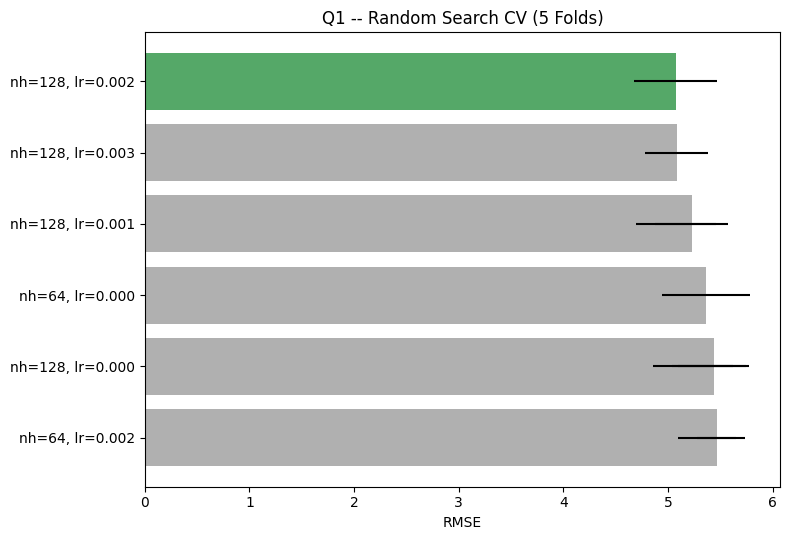

In [37]:
N_SEARCH, N_FOLDS, CV_EPOCHS = 100, 5, 150

def sample_params(rng):
    return {
        'n_hidden':   int(rng.choice([8, 16, 32, 64, 128])),
        'lr':         float(np.power(10, rng.uniform(-4, -1))),
        'mu':         float(rng.choice([0.5, 0.9, 0.95, 0.99])),
        'batch_size': int(rng.choice([16, 32, 64, 128])),
    }

results_r, best_r = random_search_cv(
    X_reg, y_reg, sample_params,
    make_factory=lambda p: (lambda: MLPRegressor(p['n_hidden'], p['lr'], p['mu'],
                                                 p['batch_size'], epochs=CV_EPOCHS)),
    metric_fn=rmse, n_search=N_SEARCH, k=N_FOLDS, maximize=False, seed=42)

print_ranking(results_r, ['n_hidden', 'lr', 'mu', 'batch_size'], 'RMSE')
plot_search_results(results_r, 'RMSE', 'Q1 -- Random Search CV (5 Folds)')

### b) Treino Final e Curvas de Custo


Treino: 617 | Validacao: 205 | Teste: 207
Config: n_hidden=128, lr=0.00166, mu=0.95, batch_size=32


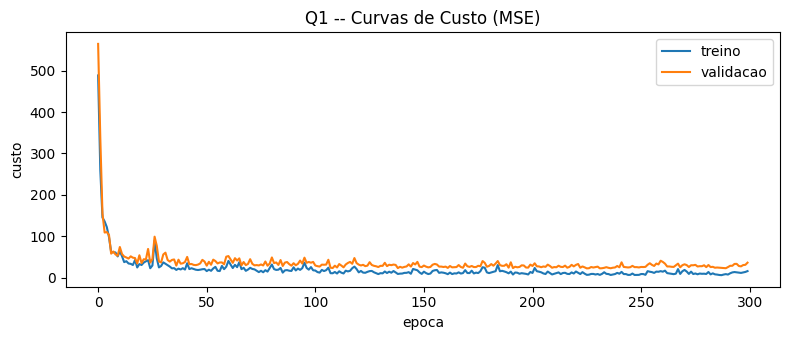

In [ ]:
# divisao treino/validacao/teste (60/20/20)
X_tr, X_va, X_te, y_tr, y_va, y_te = train_val_test_split(X_reg, y_reg)
print(f'Treino: {len(X_tr)} | Validacao: {len(X_va)} | Teste: {len(X_te)}')

mu, sigma = fit_standardize(X_tr)
X_tr_n = apply_standardize(X_tr, mu, sigma)
X_va_n = apply_standardize(X_va, mu, sigma)
X_te_n = apply_standardize(X_te, mu, sigma)

# treino final com a melhor configuracao encontrada pelo random search
mlp_reg = MLP(
    n_input=X_tr_n.shape[1], n_hidden=best_r['n_hidden'], n_output=1,
    task='regression', lr=best_r['lr'], mu=best_r['mu'],
    batch_size=best_r['batch_size'], epochs=300
)
train_losses_r, val_losses_r = mlp_reg.fit(
    X_tr_n, y_tr.reshape(-1, 1),
    X_va_n, y_va.reshape(-1, 1)
)
print(f"Config: n_hidden={best_r['n_hidden']}, lr={best_r['lr']:.5f}, "
      f"mu={best_r['mu']}, batch_size={best_r['batch_size']}")

plot_loss_curves(train_losses_r, val_losses_r, title='Q1 -- Curvas de Custo (MSE)')

### c) Metricas Finais (Treino, Validacao e Teste)

Avaliacao do modelo final nas tres particoes, com as metricas pedidas:
RMSE, MAE e MRE.

In [39]:
print_metrics(mlp_reg,
              [('Treino', X_tr_n, y_tr), ('Validacao', X_va_n, y_va), ('Teste', X_te_n, y_te)],
              [('RMSE', rmse), ('MAE', mae), ('MRE', mre)])

Treino: RMSE 3.957, MAE 2.848, MRE 0.094
Validacao: RMSE 6.003, MAE 4.401, MRE 0.140
Teste: RMSE 5.906, MAE 4.226, MRE 0.129


#### Diagnostico da Regressao


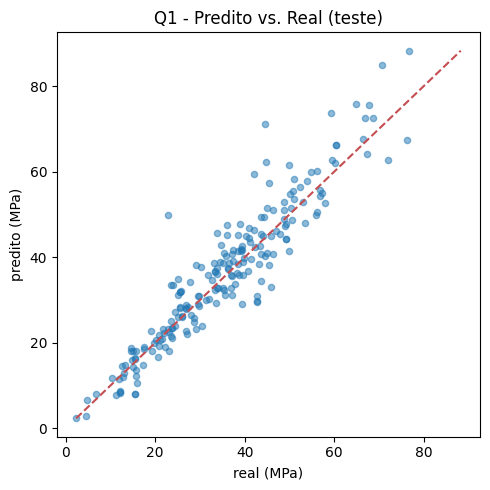

In [40]:
y_pred_te = mlp_reg.predict(X_te_n)
plot_pred_vs_real(y_te, y_pred_te, unit='MPa', title='Q1 - Predito vs. Real (teste)')

---
## Questao 2 - Classificacao: Silhuetas de Veiculos

Dataset: `vehicle.csv` - 846 amostras, 18 atributos, 4 classes (bus=0, opel=1, saab=2, van=3)

### Carregamento dos Dados

In [41]:
data_v = np.genfromtxt('data/vehicle.csv', delimiter=',')
X_clf  = data_v[:, :-1]
y_clf  = data_v[:,  -1].astype(int)

CLASS_NAMES = ['bus', 'opel', 'saab', 'van']
N_CLASSES   = 4

print(f'Amostras: {X_clf.shape[0]} | Features: {X_clf.shape[1]}')
values, counts = np.unique(y_clf, return_counts=True)
print('Distribuicao de classes:')
for v, c in zip(values, counts):
    print(f'  {CLASS_NAMES[v]:>5}: {c} amostras ({100*c/len(y_clf):.1f}%)')

Amostras: 846 | Features: 18
Distribuicao de classes:
    bus: 218 amostras (25.8%)
   opel: 212 amostras (25.1%)
   saab: 217 amostras (25.7%)
    van: 199 amostras (23.5%)


### a) Selecao de Hiperparametros via Random Search (5-Fold CV)


In [42]:
results_c, best_c = random_search_cv(
    X_clf, y_clf, sample_params,
    make_factory=lambda p: (lambda: MLPClassifier(N_CLASSES, p['n_hidden'], p['lr'],
                                                  p['mu'], p['batch_size'], epochs=CV_EPOCHS)),
    metric_fn=accuracy, n_search=N_SEARCH, k=N_FOLDS, maximize=True, seed=42)

print_ranking(results_c, ['n_hidden', 'lr', 'mu', 'batch_size'], 'Acuracia')
plot_search_results(results_c, 'Acuracia', 'Q2 - Random Search CV (5 Folds)', ylim=[0, 1.05])

Testei 100 combinacoes de hiperparametros. A melhor teve Acuracia de 0.85 (+/- 0.04) na validacao cruzada:
    n_hidden=128, lr=0.0055, mu=0.9500, batch_size=32

As 5 melhores foram:
  1. n_hidden=128, lr=0.0055, mu=0.9500, batch_size=32  ->  0.85 (+/- 0.04)
  2. n_hidden=32, lr=0.0603, mu=0.9000, batch_size=128  ->  0.84 (+/- 0.05)
  3. n_hidden=16, lr=0.0039, mu=0.9900, batch_size=64  ->  0.84 (+/- 0.03)
  4. n_hidden=128, lr=0.0064, mu=0.9900, batch_size=32  ->  0.84 (+/- 0.04)
  5. n_hidden=16, lr=0.0808, mu=0.9000, batch_size=128  ->  0.84 (+/- 0.02)


TypeError: plot_search_results() got an unexpected keyword argument 'ylim'

### b) Treino Final e Curvas de Custo


Treino: 507 | Validacao: 169 | Teste: 170
Config: n_hidden=128, lr=0.00554, mu=0.95, batch_size=32


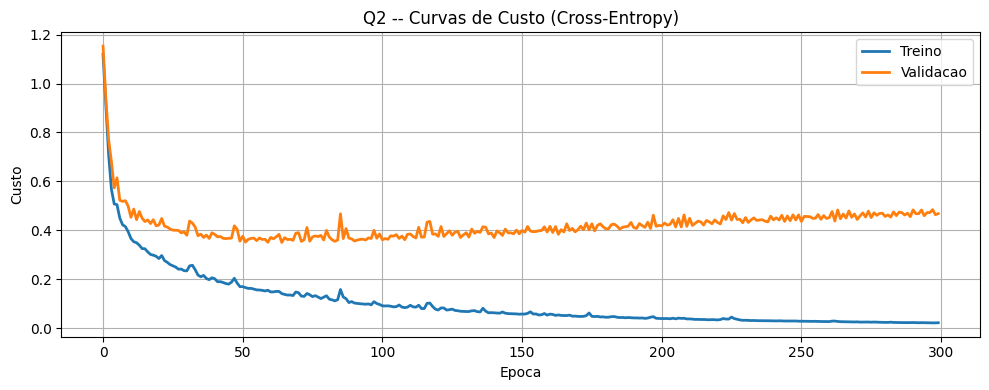

In [ ]:
# divisao treino/validacao/teste (60/20/20)
X_tr2, X_va2, X_te2, y_tr2, y_va2, y_te2 = train_val_test_split(X_clf, y_clf)
print(f'Treino: {len(X_tr2)} | Validacao: {len(X_va2)} | Teste: {len(X_te2)}')

mu2, sigma2 = fit_standardize(X_tr2)
X_tr2_n = apply_standardize(X_tr2, mu2, sigma2)
X_va2_n = apply_standardize(X_va2, mu2, sigma2)
X_te2_n = apply_standardize(X_te2, mu2, sigma2)

y_tr2_oh = one_hot(y_tr2, N_CLASSES)
y_va2_oh = one_hot(y_va2, N_CLASSES)

# treino final com a melhor configuracao encontrada pelo random search
mlp_clf = MLP(
    n_input=X_tr2_n.shape[1], n_hidden=best_c['n_hidden'], n_output=N_CLASSES,
    task='classification', lr=best_c['lr'], mu=best_c['mu'],
    batch_size=best_c['batch_size'], epochs=300
)
train_losses_c, val_losses_c = mlp_clf.fit(
    X_tr2_n, y_tr2_oh,
    X_va2_n, y_va2_oh
)
print(f"Config: n_hidden={best_c['n_hidden']}, lr={best_c['lr']:.5f}, "
      f"mu={best_c['mu']}, batch_size={best_c['batch_size']}")

plot_loss_curves(train_losses_c, val_losses_c, title='Q2 -- Curvas de Custo (Cross-Entropy)')

### c) Metricas Finais e Matriz de Confusao


In [ ]:
for name, Xn, yn in [('Treino', X_tr2_n, y_tr2), ('Validacao', X_va2_n, y_va2), ('Teste', X_te2_n, y_te2)]:
    yh = mlp_clf.predict(Xn)
    prec, rec, f1 = precision_recall_f1_macro(yn, yh, list(range(N_CLASSES)))
    print(f'{name}: acuracia {accuracy(yn, yh):.3f}, precisao {prec:.3f}, '
          f'revocacao {rec:.3f}, F1 {f1:.3f}')

In [ ]:
y_hat_te = mlp_clf.predict(X_te2_n)
cm = confusion_matrix(y_te2, y_hat_te, list(range(N_CLASSES)))
plot_cm(cm, CLASS_NAMES, title='Q2 - Matriz de confusao (teste)')

#### Desempenho por Classe


In [ ]:
print('Acerto por classe (teste):')
for nome, acerto in zip(CLASS_NAMES, cm.diagonal() / cm.sum(axis=1)):
    print(f'  {nome}: {acerto:.1%}')